# Real Data 03 - Delta Hedging

This notebook extends the real-data calibration and pricing workflow to a **hedging backtest in simulation**.

## Interpretation

This is **not** a historical realized hedge on actual future prices. Instead:

- the dependence inputs are calibrated from real semiconductor data;
- the **true world** is a regime-switching correlation model using those calibrated inputs;
- we compare the terminal P&L of:
  - an unhedged short basket call,
  - a constant-correlation hedge,
  - a regime-switching hedge.

The position convention is the same as in the synthetic study:

$$
\text{Short one basket call} + \text{dynamic hedge in the underlying stocks}.
$$

The main question is whether the real-data calibration produces a bigger effect in **hedging risk** than in time-0 price.

In [1]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (
            (candidate / "README.md").exists()
            and (candidate / "notebooks").is_dir()
            and (candidate / "scripts").is_dir()
            and (candidate / "real_simulation").is_dir()
        ):
            return candidate
    raise FileNotFoundError("Could not locate the project root. Run the notebook from inside the extracted repository.")


PROJECT_ROOT = find_project_root()
REAL_DIR = PROJECT_ROOT / "real_simulation"
DATA_DIR = REAL_DIR / "data"

In [2]:
def basket_value(prices, share_weights):
    return prices @ share_weights


def basket_call_payoff(prices, share_weights, strike):
    return np.maximum(basket_value(prices, share_weights) - strike, 0.0)


def maturity_delta(spot, share_weights, strike):
    basket_level = float(share_weights @ spot)
    if basket_level > strike:
        return share_weights.copy()
    if np.isclose(basket_level, strike):
        return 0.5 * share_weights
    return np.zeros_like(spot)


def build_transition_matrix(p01_daily, p10_daily):
    return np.array(
        [
            [1.0 - p01_daily, p01_daily],
            [p10_daily, 1.0 - p10_daily],
        ]
    )


def correlate_draws(base_draws, regime_states, chol_by_regime):
    correlated = np.empty_like(base_draws)
    for regime_value, chol in chol_by_regime.items():
        mask = regime_states == regime_value
        if np.any(mask):
            correlated[mask] = base_draws[mask] @ chol.T
    return correlated


def advance_regimes(current_regimes, transition_matrix, rng):
    prob_to_stress = transition_matrix[current_regimes, 1]
    draws = rng.random(current_regimes.size)
    return (draws < prob_to_stress).astype(np.int8)


def simulate_regime_true_world_paths(
    spot,
    rate,
    div_yield,
    vol,
    chol_calm,
    chol_stress,
    maturity,
    hedge_steps,
    n_paths,
    transition_hedge,
    start_regime,
    rng,
):
    dt = maturity / hedge_steps
    drift = (rate - div_yield - 0.5 * vol ** 2) * dt
    diffusion = vol * np.sqrt(dt)
    chol_by_regime = {0: chol_calm, 1: chol_stress}

    paths = np.empty((n_paths, hedge_steps + 1, spot.size))
    regimes = np.empty((n_paths, hedge_steps), dtype=np.int8)
    paths[:, 0, :] = spot
    current_regimes = np.full(n_paths, start_regime, dtype=np.int8)

    for step in range(hedge_steps):
        regimes[:, step] = current_regimes
        base_draws = rng.standard_normal((n_paths, spot.size))
        correlated_draws = correlate_draws(base_draws, current_regimes, chol_by_regime)
        log_increment = drift + diffusion * correlated_draws
        paths[:, step + 1, :] = paths[:, step, :] * np.exp(log_increment)

        if step < hedge_steps - 1:
            current_regimes = advance_regimes(current_regimes, transition_hedge, rng)

    return paths, regimes


def constant_model_terminal_factors(spot, rate, div_yield, vol, tau, chol_constant, n_samples, rng):
    if tau <= 0.0:
        return np.ones((n_samples, spot.size))
    drift = (rate - div_yield - 0.5 * vol ** 2) * tau
    diffusion = vol * np.sqrt(tau)
    shocks = rng.standard_normal((n_samples, spot.size)) @ chol_constant.T
    return np.exp(drift + diffusion * shocks)


def regime_model_terminal_factors(
    spot,
    rate,
    div_yield,
    vol,
    hedge_dt,
    steps_remaining,
    chol_calm,
    chol_stress,
    transition_hedge,
    start_regime,
    n_samples,
    rng,
):
    if steps_remaining <= 0:
        return np.ones((n_samples, spot.size))

    drift = (rate - div_yield - 0.5 * vol ** 2) * hedge_dt
    diffusion = vol * np.sqrt(hedge_dt)
    chol_by_regime = {0: chol_calm, 1: chol_stress}
    current_regimes = np.full(n_samples, start_regime, dtype=np.int8)
    log_factors = np.zeros((n_samples, spot.size))

    for step in range(steps_remaining):
        base_draws = rng.standard_normal((n_samples, spot.size))
        correlated_draws = correlate_draws(base_draws, current_regimes, chol_by_regime)
        log_factors += drift + diffusion * correlated_draws
        if step < steps_remaining - 1:
            current_regimes = advance_regimes(current_regimes, transition_hedge, rng)

    return np.exp(log_factors)


def price_and_delta_from_terminal_factors(spot, terminal_factors, share_weights, strike, rate, tau, bump_fraction):
    terminal_prices = terminal_factors * spot
    discount = np.exp(-rate * tau)
    payoff = basket_call_payoff(terminal_prices, share_weights, strike)
    price = discount * payoff.mean()

    bump_sizes = bump_fraction * np.maximum(spot, 1.0)
    deltas = np.empty_like(spot)
    for asset_idx in range(spot.size):
        up_spot = spot[asset_idx] + bump_sizes[asset_idx]
        down_spot = max(spot[asset_idx] - bump_sizes[asset_idx], 1e-8)
        denominator = up_spot - down_spot

        up_terminal = terminal_prices.copy()
        down_terminal = terminal_prices.copy()
        up_terminal[:, asset_idx] = terminal_factors[:, asset_idx] * up_spot
        down_terminal[:, asset_idx] = terminal_factors[:, asset_idx] * down_spot

        up_payoff = basket_call_payoff(up_terminal, share_weights, strike)
        down_payoff = basket_call_payoff(down_terminal, share_weights, strike)
        deltas[asset_idx] = discount * (up_payoff.mean() - down_payoff.mean()) / denominator

    return float(price), deltas


def constant_model_price_and_delta(spot, tau, share_weights, strike, rate, div_yield, vol, chol_constant, n_samples, bump_fraction, rng):
    if tau <= 0.0:
        payoff = float(basket_call_payoff(spot[None, :], share_weights, strike)[0])
        return payoff, maturity_delta(spot, share_weights, strike)
    terminal_factors = constant_model_terminal_factors(spot, rate, div_yield, vol, tau, chol_constant, n_samples, rng)
    return price_and_delta_from_terminal_factors(spot, terminal_factors, share_weights, strike, rate, tau, bump_fraction)


def regime_model_price_and_delta(
    spot,
    steps_remaining,
    current_regime,
    share_weights,
    strike,
    rate,
    div_yield,
    vol,
    hedge_dt,
    chol_calm,
    chol_stress,
    transition_hedge,
    n_samples,
    bump_fraction,
    rng,
):
    tau = steps_remaining * hedge_dt
    if steps_remaining <= 0:
        payoff = float(basket_call_payoff(spot[None, :], share_weights, strike)[0])
        return payoff, maturity_delta(spot, share_weights, strike)
    terminal_factors = regime_model_terminal_factors(
        spot,
        rate,
        div_yield,
        vol,
        hedge_dt,
        steps_remaining,
        chol_calm,
        chol_stress,
        transition_hedge,
        current_regime,
        n_samples,
        rng,
    )
    return price_and_delta_from_terminal_factors(spot, terminal_factors, share_weights, strike, rate, tau, bump_fraction)


def pnl_summary(pnl):
    return {
        "mean_pnl": float(np.mean(pnl)),
        "std_pnl": float(np.std(pnl, ddof=1)),
        "median_pnl": float(np.median(pnl)),
        "q05_pnl": float(np.quantile(pnl, 0.05)),
        "q01_pnl": float(np.quantile(pnl, 0.01)),
        "min_pnl": float(np.min(pnl)),
        "max_pnl": float(np.max(pnl)),
    }


def evaluate_hedger(true_paths, true_regimes, hedge_model, pricing_inputs, base_seed):
    time_start = time.perf_counter()

    if hedge_model == "constant":
        initial_price, initial_delta = constant_model_price_and_delta(
            spot=pricing_inputs["spot"],
            tau=pricing_inputs["maturity"],
            share_weights=pricing_inputs["share_weights"],
            strike=pricing_inputs["strike"],
            rate=pricing_inputs["rate"],
            div_yield=pricing_inputs["div_yield"],
            vol=pricing_inputs["vol"],
            chol_constant=pricing_inputs["chol_constant"],
            n_samples=pricing_inputs["initial_price_mc_paths"],
            bump_fraction=pricing_inputs["bump_fraction"],
            rng=np.random.default_rng(base_seed + 1),
        )
    else:
        initial_price, initial_delta = regime_model_price_and_delta(
            spot=pricing_inputs["spot"],
            steps_remaining=pricing_inputs["hedge_steps"],
            current_regime=pricing_inputs["start_regime"],
            share_weights=pricing_inputs["share_weights"],
            strike=pricing_inputs["strike"],
            rate=pricing_inputs["rate"],
            div_yield=pricing_inputs["div_yield"],
            vol=pricing_inputs["vol"],
            hedge_dt=pricing_inputs["hedge_dt"],
            chol_calm=pricing_inputs["chol_calm"],
            chol_stress=pricing_inputs["chol_stress"],
            transition_hedge=pricing_inputs["transition_hedge"],
            n_samples=pricing_inputs["initial_price_mc_paths"],
            bump_fraction=pricing_inputs["bump_fraction"],
            rng=np.random.default_rng(base_seed + 2),
        )

    terminal_payoff = basket_call_payoff(true_paths[:, -1, :], pricing_inputs["share_weights"], pricing_inputs["strike"])
    n_paths = true_paths.shape[0]
    cash_account = np.full(n_paths, initial_price) - true_paths[:, 0, :] @ initial_delta
    delta_holdings = np.tile(initial_delta, (n_paths, 1))

    for step in range(pricing_inputs["hedge_steps"] - 1):
        next_spots = true_paths[:, step + 1, :]
        cash_account *= np.exp(pricing_inputs["rate"] * pricing_inputs["hedge_dt"])
        portfolio_before = cash_account + np.sum(delta_holdings * next_spots, axis=1)
        remaining_steps = pricing_inputs["hedge_steps"] - (step + 1)
        new_deltas = np.empty_like(delta_holdings)

        for path_idx in range(n_paths):
            state_rng = np.random.default_rng(base_seed + 10000 * (step + 1) + path_idx)
            if hedge_model == "constant":
                _, state_delta = constant_model_price_and_delta(
                    spot=next_spots[path_idx],
                    tau=remaining_steps * pricing_inputs["hedge_dt"],
                    share_weights=pricing_inputs["share_weights"],
                    strike=pricing_inputs["strike"],
                    rate=pricing_inputs["rate"],
                    div_yield=pricing_inputs["div_yield"],
                    vol=pricing_inputs["vol"],
                    chol_constant=pricing_inputs["chol_constant"],
                    n_samples=pricing_inputs["delta_mc_paths"],
                    bump_fraction=pricing_inputs["bump_fraction"],
                    rng=state_rng,
                )
            else:
                _, state_delta = regime_model_price_and_delta(
                    spot=next_spots[path_idx],
                    steps_remaining=remaining_steps,
                    current_regime=int(true_regimes[path_idx, step + 1]),
                    share_weights=pricing_inputs["share_weights"],
                    strike=pricing_inputs["strike"],
                    rate=pricing_inputs["rate"],
                    div_yield=pricing_inputs["div_yield"],
                    vol=pricing_inputs["vol"],
                    hedge_dt=pricing_inputs["hedge_dt"],
                    chol_calm=pricing_inputs["chol_calm"],
                    chol_stress=pricing_inputs["chol_stress"],
                    transition_hedge=pricing_inputs["transition_hedge"],
                    n_samples=pricing_inputs["delta_mc_paths"],
                    bump_fraction=pricing_inputs["bump_fraction"],
                    rng=state_rng,
                )
            new_deltas[path_idx] = state_delta

        cash_account = portfolio_before - np.sum(new_deltas * next_spots, axis=1)
        delta_holdings = new_deltas

    cash_account *= np.exp(pricing_inputs["rate"] * pricing_inputs["hedge_dt"])
    pnl = cash_account + np.sum(delta_holdings * true_paths[:, -1, :], axis=1) - terminal_payoff

    return {
        "runtime_seconds": float(time.perf_counter() - time_start),
        "initial_price": float(initial_price),
        "initial_delta": initial_delta,
        "terminal_payoff": terminal_payoff,
        "pnl": pnl,
    }

In [3]:
basket_definition = pd.read_csv(DATA_DIR / "real_basket_definition.csv")
pricing_config = pd.read_csv(DATA_DIR / "real_basket_pricing_config.csv").rename(columns={"Unnamed: 0": "parameter"})
constant_corr = pd.read_csv(DATA_DIR / "constant_correlation_matrix.csv", index_col=0)
calm_corr = pd.read_csv(DATA_DIR / "calm_correlation_matrix.csv", index_col=0)
stress_corr = pd.read_csv(DATA_DIR / "stress_correlation_matrix.csv", index_col=0)
transition_matrix = pd.read_csv(DATA_DIR / "regime_transition_matrix.csv").rename(columns={"Unnamed: 0": "state"}).set_index("state")

tickers = basket_definition["ticker"].tolist()
spot = basket_definition["spot"].to_numpy(dtype=float)
vol = basket_definition["annualized_volatility"].to_numpy(dtype=float)
share_weights = basket_definition["share_weight"].to_numpy(dtype=float)

rate = float(pricing_config.loc[pricing_config["parameter"] == "risk_free_rate", "value"].iloc[0])
maturity = float(pricing_config.loc[pricing_config["parameter"] == "maturity_years", "value"].iloc[0])
strike = float(pricing_config.loc[pricing_config["parameter"] == "strike", "value"].iloc[0])
start_regime_label = pricing_config.loc[pricing_config["parameter"] == "start_regime", "value"].iloc[0]
start_regime = 1 if str(start_regime_label).strip().lower() == "stress" else 0

p01_daily = float(transition_matrix.loc["calm", "to_stress"])
p10_daily = float(transition_matrix.loc["stress", "to_calm"])
daily_transition = build_transition_matrix(p01_daily, p10_daily)

hedge_steps = 12
transition_hedge = np.linalg.matrix_power(daily_transition, 252 // hedge_steps)

n_true_world_paths = 150
delta_mc_paths = 1000
initial_price_mc_paths = 12000
bump_fraction = 0.01
div_yield = np.zeros(len(tickers))

hedge_config = pd.Series(
    {
        "n_assets": len(tickers),
        "hedge_steps": hedge_steps,
        "true_world_paths": n_true_world_paths,
        "delta_mc_paths": delta_mc_paths,
        "initial_price_mc_paths": initial_price_mc_paths,
        "bump_fraction": bump_fraction,
        "start_regime": start_regime_label,
        "daily_p01": p01_daily,
        "daily_p10": p10_daily,
    },
    name="value",
)

display(Markdown("## Hedging configuration"))
display(hedge_config.to_frame())

display(Markdown("## Basket definition reused from pricing notebook"))
display(basket_definition)

## Hedging configuration

,value
n_assets,5
hedge_steps,12
true_world_paths,150
delta_mc_paths,1000
initial_price_mc_paths,12000
bump_fraction,0.0100
start_regime,calm
daily_p01,0.0173
daily_p10,0.0980


## Basket definition reused from pricing notebook

,ticker,spot,annualized_volatility,allocation_weight,share_weight,initial_dollar_contribution
0,NVDA,180.2500,0.5093,0.2000,0.1110,20.0000
1,AVGO,322.1600,0.4126,0.2000,0.0621,20.0000
2,MU,426.1300,0.4997,0.2000,0.0469,20.0000
3,AMAT,341.5300,0.4504,0.2000,0.0586,20.0000
4,LRCX,212.2000,0.4685,0.2000,0.0943,20.0000


In [4]:
pricing_inputs = {
    "spot": spot,
    "share_weights": share_weights,
    "strike": strike,
    "rate": rate,
    "div_yield": div_yield,
    "vol": vol,
    "maturity": maturity,
    "hedge_steps": hedge_steps,
    "hedge_dt": maturity / hedge_steps,
    "delta_mc_paths": delta_mc_paths,
    "initial_price_mc_paths": initial_price_mc_paths,
    "bump_fraction": bump_fraction,
    "chol_constant": np.linalg.cholesky(constant_corr.to_numpy()),
    "chol_calm": np.linalg.cholesky(calm_corr.to_numpy()),
    "chol_stress": np.linalg.cholesky(stress_corr.to_numpy()),
    "transition_hedge": transition_hedge,
    "start_regime": start_regime,
}

true_paths, true_regimes = simulate_regime_true_world_paths(
    spot=spot,
    rate=rate,
    div_yield=div_yield,
    vol=vol,
    chol_calm=pricing_inputs["chol_calm"],
    chol_stress=pricing_inputs["chol_stress"],
    maturity=maturity,
    hedge_steps=hedge_steps,
    n_paths=n_true_world_paths,
    transition_hedge=transition_hedge,
    start_regime=start_regime,
    rng=np.random.default_rng(2026031701),
)

constant_result = evaluate_hedger(
    true_paths=true_paths,
    true_regimes=true_regimes,
    hedge_model="constant",
    pricing_inputs=pricing_inputs,
    base_seed=2026031702,
)
regime_result = evaluate_hedger(
    true_paths=true_paths,
    true_regimes=true_regimes,
    hedge_model="regime",
    pricing_inputs=pricing_inputs,
    base_seed=2026031703,
)

unhedged_terminal_payoff = constant_result["terminal_payoff"]
unhedged_pnl = constant_result["initial_price"] * np.exp(rate * maturity) - unhedged_terminal_payoff

initial_hedge_table = pd.DataFrame(
    [
        {
            "strategy": "Constant-correlation hedge",
            "initial_price": constant_result["initial_price"],
            **{f"delta_{ticker}": delta for ticker, delta in zip(tickers, constant_result["initial_delta"])},
        },
        {
            "strategy": "Regime-switching hedge",
            "initial_price": regime_result["initial_price"],
            **{f"delta_{ticker}": delta for ticker, delta in zip(tickers, regime_result["initial_delta"])},
        },
    ]
)

hedging_summary = pd.DataFrame(
    [
        {
            "strategy": "Unhedged short option",
            "initial_price": constant_result["initial_price"],
            "initial_price_diff_vs_regime": constant_result["initial_price"] - regime_result["initial_price"],
            **pnl_summary(unhedged_pnl),
            "avg_stress_fraction": float(true_regimes.mean()),
            "runtime_seconds": 0.0,
        },
        {
            "strategy": "Constant-correlation hedge",
            "initial_price": constant_result["initial_price"],
            "initial_price_diff_vs_regime": constant_result["initial_price"] - regime_result["initial_price"],
            **pnl_summary(constant_result["pnl"]),
            "avg_stress_fraction": float(true_regimes.mean()),
            "runtime_seconds": constant_result["runtime_seconds"],
        },
        {
            "strategy": "Regime-switching hedge",
            "initial_price": regime_result["initial_price"],
            "initial_price_diff_vs_regime": 0.0,
            **pnl_summary(regime_result["pnl"]),
            "avg_stress_fraction": float(true_regimes.mean()),
            "runtime_seconds": regime_result["runtime_seconds"],
        },
    ]
)
unhedged_std = hedging_summary.loc[hedging_summary["strategy"] == "Unhedged short option", "std_pnl"].iloc[0]
hedging_summary["std_reduction_vs_unhedged"] = 1.0 - hedging_summary["std_pnl"] / unhedged_std
hedging_summary.loc[hedging_summary["strategy"] == "Unhedged short option", "std_reduction_vs_unhedged"] = 0.0

pathwise_pnl = pd.DataFrame(
    {
        "path_id": np.arange(n_true_world_paths),
        "stress_fraction": true_regimes.mean(axis=1),
        "terminal_payoff": unhedged_terminal_payoff,
        "Unhedged short option": unhedged_pnl,
        "Constant-correlation hedge": constant_result["pnl"],
        "Regime-switching hedge": regime_result["pnl"],
    }
)

premium_adjustment_to_regime = (constant_result["initial_price"] - regime_result["initial_price"]) * np.exp(rate * maturity)
pathwise_pnl["Constant-correlation hedge (adjusted to regime premium)"] = (
    pathwise_pnl["Constant-correlation hedge"] - premium_adjustment_to_regime
)

clean_comparison = pd.DataFrame(
    [
        {
            "strategy": "Constant-correlation hedge (adjusted)",
            "premium_basis": "Regime initial premium",
            "terminal_adjustment_applied": premium_adjustment_to_regime,
            **pnl_summary(pathwise_pnl["Constant-correlation hedge (adjusted to regime premium)"]),
        },
        {
            "strategy": "Regime-switching hedge",
            "premium_basis": "Regime initial premium",
            "terminal_adjustment_applied": 0.0,
            **pnl_summary(pathwise_pnl["Regime-switching hedge"]),
        },
    ]
)

clean_gap = pd.DataFrame(
    [
        {
            "comparison_basis": "Both hedges measured at regime initial premium",
            "premium_adjustment_to_regime": premium_adjustment_to_regime,
            "std_gap_constant_minus_regime": (
                clean_comparison.loc[clean_comparison["strategy"] == "Constant-correlation hedge (adjusted)", "std_pnl"].iloc[0]
                - clean_comparison.loc[clean_comparison["strategy"] == "Regime-switching hedge", "std_pnl"].iloc[0]
            ),
            "q05_gap_regime_minus_constant": (
                clean_comparison.loc[clean_comparison["strategy"] == "Regime-switching hedge", "q05_pnl"].iloc[0]
                - clean_comparison.loc[clean_comparison["strategy"] == "Constant-correlation hedge (adjusted)", "q05_pnl"].iloc[0]
            ),
            "q01_gap_regime_minus_constant": (
                clean_comparison.loc[clean_comparison["strategy"] == "Regime-switching hedge", "q01_pnl"].iloc[0]
                - clean_comparison.loc[clean_comparison["strategy"] == "Constant-correlation hedge (adjusted)", "q01_pnl"].iloc[0]
            ),
            "mean_gap_regime_minus_constant": (
                clean_comparison.loc[clean_comparison["strategy"] == "Regime-switching hedge", "mean_pnl"].iloc[0]
                - clean_comparison.loc[clean_comparison["strategy"] == "Constant-correlation hedge (adjusted)", "mean_pnl"].iloc[0]
            ),
        }
    ]
)

display(Markdown("## Initial hedge table"))
display(initial_hedge_table)

display(Markdown("## Hedging summary"))
display(hedging_summary)

display(Markdown("## Cleaner comparison on a common premium basis"))
display(clean_comparison)
display(clean_gap)

## Initial hedge table

,strategy,initial_price,delta_NVDA,delta_AVGO,delta_MU,delta_AMAT,delta_LRCX
0,Constant-correlation hedge,17.9864,0.0693,0.0369,0.0293,0.0362,0.0588
1,Regime-switching hedge,17.4997,0.0697,0.0369,0.0296,0.0366,0.0594


## Hedging summary

,strategy,initial_price,initial_price_diff_vs_regime,mean_pnl,std_pnl,median_pnl,q05_pnl,q01_pnl,min_pnl,max_pnl,avg_stress_fraction,runtime_seconds,std_reduction_vs_unhedged
0,Unhedged short option,17.9864,0.4867,-0.9479,34.7380,18.7204,-92.9287,-122.9983,-144.2379,18.7204,0.1167,0.0000,0.0000
1,Constant-correlation hedge,17.9864,0.4867,0.6170,3.6859,0.6230,-5.5049,-8.5101,-14.0696,9.5855,0.1167,0.4326,0.8939
2,Regime-switching hedge,17.4997,0.0000,0.1047,3.6399,0.1639,-6.6222,-8.9213,-15.1099,8.8490,0.1167,1.3251,0.8952


## Cleaner comparison on a common premium basis

,strategy,premium_basis,terminal_adjustment_applied,mean_pnl,std_pnl,median_pnl,q05_pnl,q01_pnl,min_pnl,max_pnl
0,Constant-correlation hedge (adjusted),Regime initial premium,0.5066,0.1105,3.6859,0.1165,-6.0115,-9.0167,-14.5761,9.0790
1,Regime-switching hedge,Regime initial premium,0.0000,0.1047,3.6399,0.1639,-6.6222,-8.9213,-15.1099,8.8490


,comparison_basis,premium_adjustment_to_regime,std_gap_constant_minus_regime,q05_gap_regime_minus_constant,q01_gap_regime_minus_constant,mean_gap_regime_minus_constant
0,Both hedges measured at regime initial premium,0.5066,0.0460,-0.6107,0.0954,-0.0058


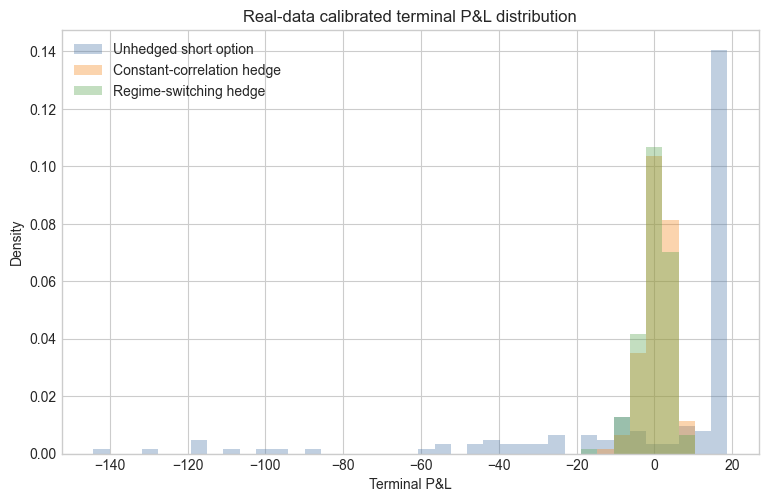

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5))
bins = np.linspace(
    pathwise_pnl[["Unhedged short option", "Constant-correlation hedge", "Regime-switching hedge"]].min().min(),
    pathwise_pnl[["Unhedged short option", "Constant-correlation hedge", "Regime-switching hedge"]].max().max(),
    40,
)
for column, color in [
    ("Unhedged short option", "#4c78a8"),
    ("Constant-correlation hedge", "#f58518"),
    ("Regime-switching hedge", "#54a24b"),
]:
    ax.hist(pathwise_pnl[column], bins=bins, alpha=0.35, density=True, label=column, color=color)

ax.set_title("Real-data calibrated terminal P&L distribution")
ax.set_xlabel("Terminal P&L")
ax.set_ylabel("Density")
ax.legend()
plt.show()

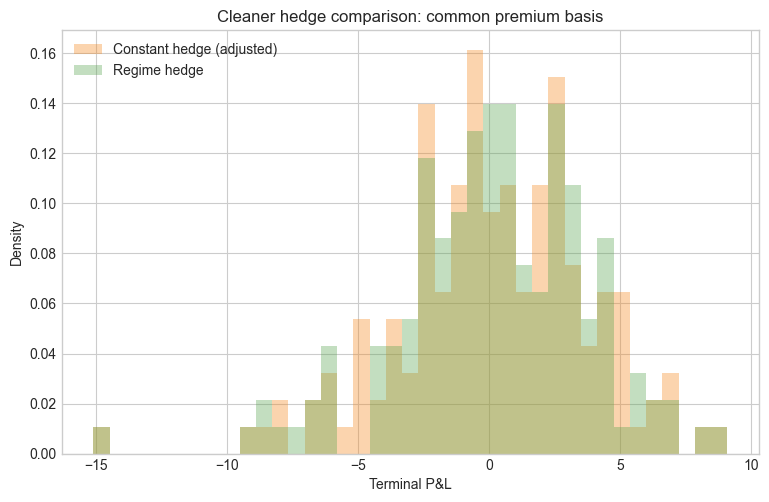

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5))
bins = np.linspace(
    pathwise_pnl[["Constant-correlation hedge (adjusted to regime premium)", "Regime-switching hedge"]].min().min(),
    pathwise_pnl[["Constant-correlation hedge (adjusted to regime premium)", "Regime-switching hedge"]].max().max(),
    40,
)
ax.hist(
    pathwise_pnl["Constant-correlation hedge (adjusted to regime premium)"],
    bins=bins,
    alpha=0.35,
    density=True,
    label="Constant hedge (adjusted)",
    color="#f58518",
)
ax.hist(
    pathwise_pnl["Regime-switching hedge"],
    bins=bins,
    alpha=0.35,
    density=True,
    label="Regime hedge",
    color="#54a24b",
)
ax.set_title("Cleaner hedge comparison: common premium basis")
ax.set_xlabel("Terminal P&L")
ax.set_ylabel("Density")
ax.legend()
plt.show()

In [7]:
worst_constant = pathwise_pnl.nsmallest(8, "Constant-correlation hedge")[
    [
        "path_id",
        "stress_fraction",
        "terminal_payoff",
        "Unhedged short option",
        "Constant-correlation hedge",
        "Regime-switching hedge",
    ]
]
display(Markdown("## Worst constant-hedge paths"))
display(worst_constant)

## Worst constant-hedge paths

,path_id,stress_fraction,terminal_payoff,Unhedged short option,Constant-correlation hedge,Regime-switching hedge
67,67,0.1667,0.0000,18.7204,-14.0696,-15.1099
85,85,0.0833,0.0000,18.7204,-8.8424,-8.6560
144,144,0.0000,28.7443,-10.0239,-8.1644,-7.1086
142,142,0.0000,0.0000,18.7204,-7.6887,-9.1762
36,36,0.0833,0.0000,18.7204,-7.2840,-6.4234
79,79,0.1667,105.3748,-86.6544,-6.2314,-5.9688
101,101,0.0833,11.2750,7.4454,-6.1144,-7.9333
52,52,0.1667,35.3930,-16.6726,-5.6198,-6.3069


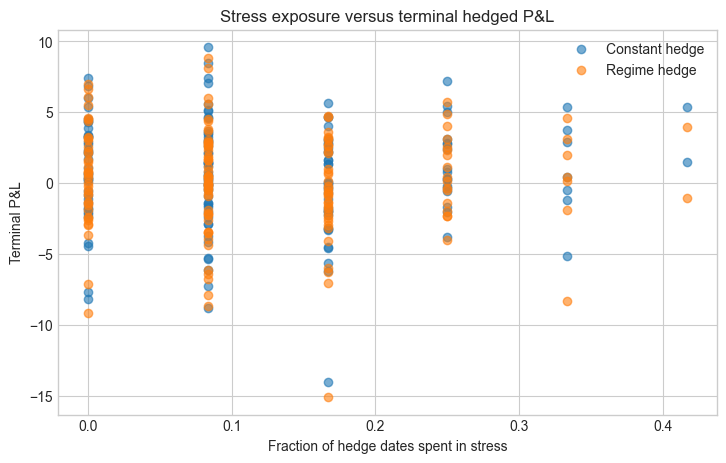

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.scatter(pathwise_pnl["stress_fraction"], pathwise_pnl["Constant-correlation hedge"], alpha=0.6, label="Constant hedge")
ax.scatter(pathwise_pnl["stress_fraction"], pathwise_pnl["Regime-switching hedge"], alpha=0.6, label="Regime hedge")
ax.set_title("Stress exposure versus terminal hedged P&L")
ax.set_xlabel("Fraction of hedge dates spent in stress")
ax.set_ylabel("Terminal P&L")
ax.legend()
plt.show()

In [9]:
initial_hedge_table.to_csv(DATA_DIR / "real_basket_initial_hedge_table.csv", index=False)
hedging_summary.to_csv(DATA_DIR / "real_basket_hedging_summary.csv", index=False)
pathwise_pnl.to_csv(DATA_DIR / "real_basket_hedging_pathwise_pnl.csv", index=False)
clean_comparison.to_csv(DATA_DIR / "real_basket_hedging_clean_comparison.csv", index=False)
clean_gap.to_csv(DATA_DIR / "real_basket_hedging_clean_gap.csv", index=False)
hedge_config.to_csv(DATA_DIR / "real_basket_hedging_config.csv")

print(f"Saved initial hedge table to {DATA_DIR / 'real_basket_initial_hedge_table.csv'}")
print(f"Saved hedging summary to {DATA_DIR / 'real_basket_hedging_summary.csv'}")
print(f"Saved pathwise P&L to {DATA_DIR / 'real_basket_hedging_pathwise_pnl.csv'}")
print(f"Saved clean hedge comparison to {DATA_DIR / 'real_basket_hedging_clean_comparison.csv'}")
print(f"Saved clean hedge gap table to {DATA_DIR / 'real_basket_hedging_clean_gap.csv'}")
print(f"Saved hedging config to {DATA_DIR / 'real_basket_hedging_config.csv'}")

Saved initial hedge table to /Users/hamzaahmed/Multi-Asset Option Pricing/real_simulation/data/real_basket_initial_hedge_table.csv
Saved hedging summary to /Users/hamzaahmed/Multi-Asset Option Pricing/real_simulation/data/real_basket_hedging_summary.csv
Saved pathwise P&L to /Users/hamzaahmed/Multi-Asset Option Pricing/real_simulation/data/real_basket_hedging_pathwise_pnl.csv
Saved clean hedge comparison to /Users/hamzaahmed/Multi-Asset Option Pricing/real_simulation/data/real_basket_hedging_clean_comparison.csv
Saved clean hedge gap table to /Users/hamzaahmed/Multi-Asset Option Pricing/real_simulation/data/real_basket_hedging_clean_gap.csv
Saved hedging config to /Users/hamzaahmed/Multi-Asset Option Pricing/real_simulation/data/real_basket_hedging_config.csv


## What this notebook adds

This notebook completes the real-data analogue of the synthetic hedging experiment:

- real historical data calibrates the dependence structure;
- the future world is simulated under the calibrated regime model;
- hedge quality is evaluated through the terminal P&L distribution rather than price alone.

If the same pattern appears here as in the synthetic study, the real-data stage will support the same conclusion: pricing differences may be modest, but hedging tail risk can still be sensitive to correlation misspecification.